# Prop Firm Challenge Simulator — Analysis Notebook

This notebook is the **dashboard** on top of the `.py` engine. Run cells top-to-bottom
(Shift+Enter). Change `FIRM` in the setup cell to switch firms; everything below
re-runs against that firm's rules.

**Firm keys:** `apex_eod`, `apex_intraday`, `lucid`, `tradeify_select`, `tradeify_growth`, `mffu_rapid`, `topstep`


In [7]:
import os, sys

# Put the ACTUAL absolute path to the folder holding the .py files here.
# In VS Code: right-click firms.py in the explorer -> "Copy Path".
PROJECT_DIR = r"C:\Users\2115h\Desktop\Trading\Quant\Propfirm Convex Analysis\Rules"   # <-- edit this

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

In [13]:
# --- Setup ---
import sys, os
sys.path.append(os.getcwd())          # notebook lives in the propfirm_sim/ folder
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from Firms import FIRMS, get_firm
from Strategy import SyntheticStrategy, EmpiricalStrategy
from Engine import simulate
from Analysis import (plot_equity_paths, plot_strategy_comparison,
                      plot_risk_rr_heatmap, compute_risk_rr_grid)

# ====== CHANGE THESE TWO LINES TO RETUNE EVERYTHING ======
FIRM = get_firm("apex_intraday")   # <-- switch firm here
RISK_PCT = 1.0                     # % of $50k risked per trade
TRADES_PER_DAY = 3
# =========================================================
RISK_DOLLARS = FIRM.start_balance * RISK_PCT / 100.0
print(f"{FIRM.name}: target ${FIRM.target_equity:,.0f} | floor ${FIRM.initial_floor:,.0f} "
      f"| dd={FIRM.dd_type.value} | trail_lock={FIRM.trail_lock} "
      f"| DLL={FIRM.daily_loss_limit} ({FIRM.dll_behavior.value}) "
      f"| consistency={FIRM.consistency_pct} | min_days={FIRM.min_days}")


Apex (Intraday Trailing): target $53,000 | floor $48,000 | dd=intraday_trail | trail_lock=50000 | DLL=None (none) | consistency=None | min_days=1


## All firm rules at a glance

In [14]:
for k, f in FIRMS.items():
    print(f"{k:17s} | {f.name:26s} | dd={f.dd_type.value:14s} lock={str(f.trail_lock):7s} "
          f"DLL={str(f.daily_loss_limit):5s}({f.dll_behavior.value:4s}) "
          f"cons={str(f.consistency_pct):4s} min_days={f.min_days}")


apex_eod          | Apex (EOD Trailing)        | dd=eod_trail      lock=50000   DLL=1000 (hard) cons=None min_days=1
apex_intraday     | Apex (Intraday Trailing)   | dd=intraday_trail lock=50000   DLL=None (none) cons=None min_days=1
lucid             | Lucid (LucidPro)           | dd=eod_trail      lock=50000   DLL=1200 (hard) cons=None min_days=1
tradeify_select   | Tradeify (Select)          | dd=eod_trail      lock=50000   DLL=None (none) cons=0.4  min_days=3
tradeify_growth   | Tradeify (Growth)          | dd=eod_trail      lock=50000   DLL=1250 (soft) cons=None min_days=1
mffu_rapid        | MyFundedFutures (Rapid)    | dd=intraday_trail lock=None    DLL=None (none) cons=0.5  min_days=2
topstep           | Topstep (Combine)          | dd=eod_trail      lock=50000   DLL=None (none) cons=0.5  min_days=2


## 1) Equity paths by risk geometry (EV = 0)

Green = pass, red = fail, grey = still ongoing. All six panels have **zero edge** —
only the R:R geometry changes. Pass rates differ anyway: that's the convexity you're
exploiting. Lines are the firm's real target/floor.

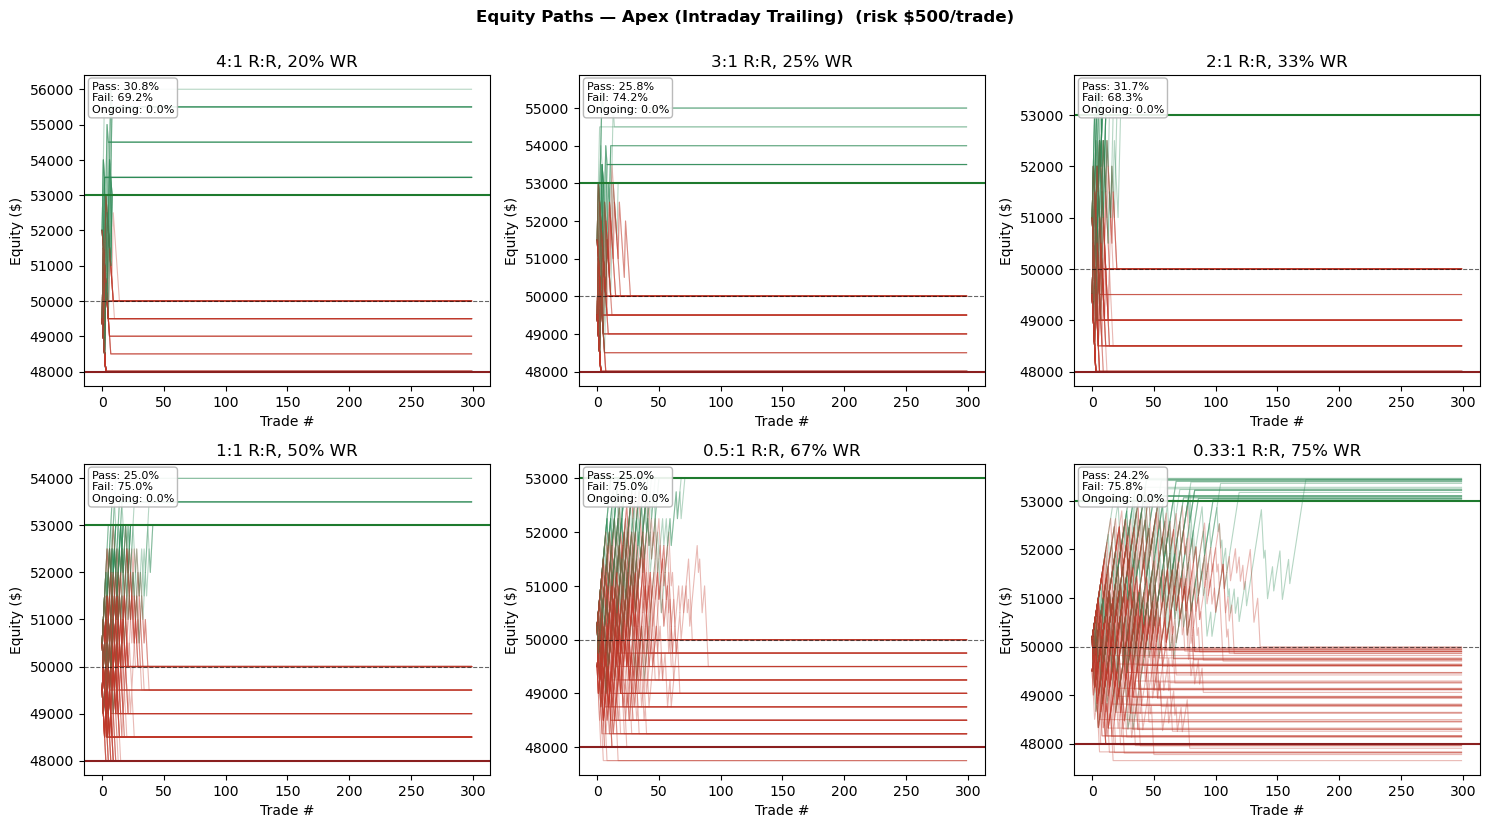

In [15]:
ev0_geoms = [(rr, 1.0/(rr+1.0)) for rr in (4, 3, 2, 1, 0.5, 0.33)]
fig = plot_equity_paths(FIRM, ev0_geoms, risk_per_trade=RISK_DOLLARS,
                        n_show=120, max_trades=300, trades_per_day=TRADES_PER_DAY)
plt.show()


## 2) Strategy comparison — pass rate, outcome mix, speed to target

Same six geometries at EV=0. Swap `strat_set` for your real strategies (see the last
cell) to compare 

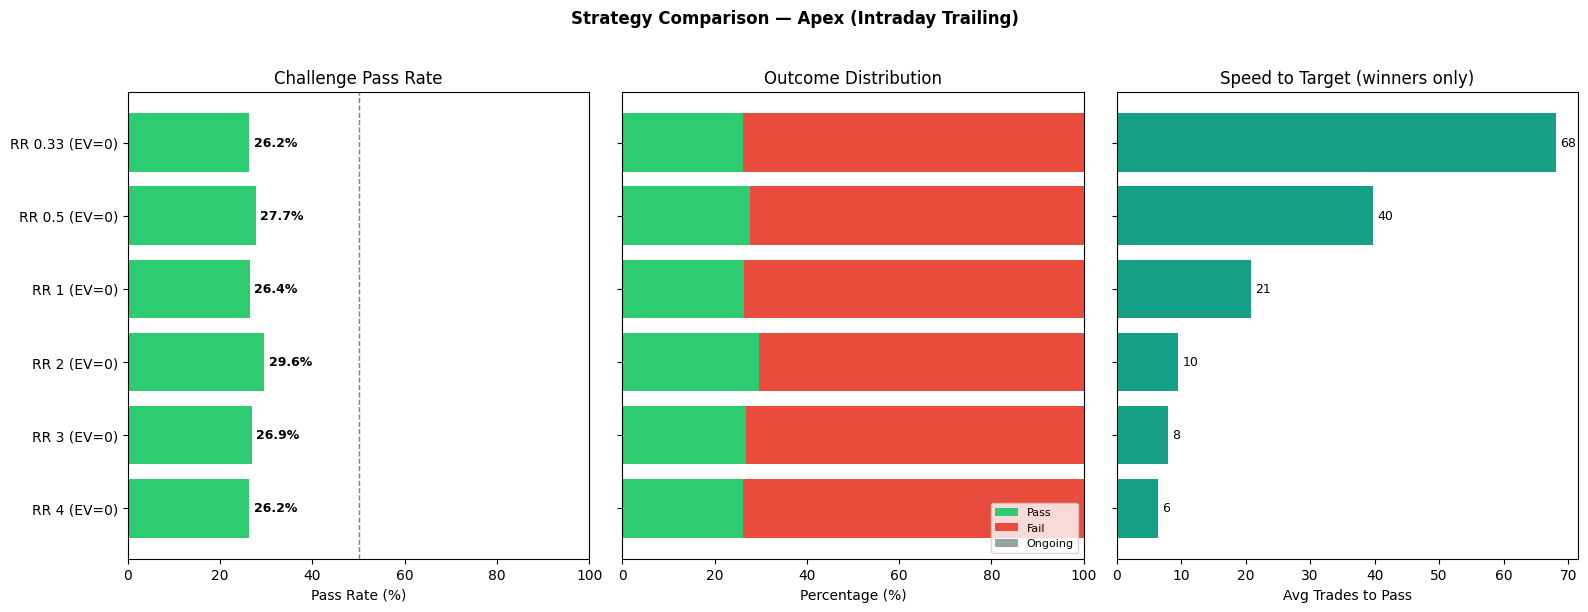

In [4]:
strat_set = [SyntheticStrategy.from_edge(rr, edge_R=0.0, name=f"RR {rr:g} (EV=0)")
             for rr in (0.33, 0.5, 1, 2, 3, 4)]
fig = plot_strategy_comparison(FIRM, strat_set, risk_per_trade=RISK_DOLLARS,
                               n_paths=4000, trades_per_day=TRADES_PER_DAY)
plt.show()


## 3) Risk/trade × R:R heatmap (fixed +0.10R edge)

Holds a small positive edge constant and sweeps **risk % (rows)** against **R:R geometry
(columns)**. Colour = pass rate, second number = avg trades to pass. This is your
optimizer: read off the sizing that maximizes P(pass) for this firm.

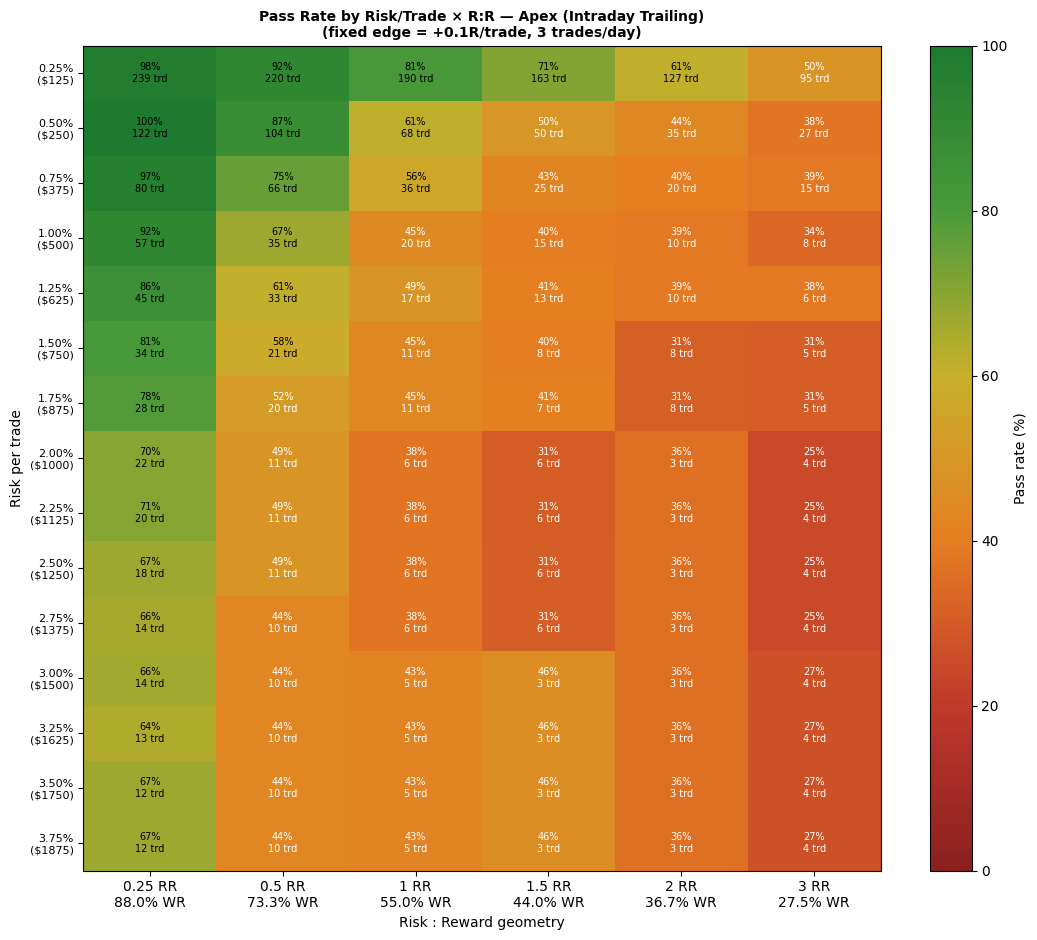

Best cell: risk 0.5% x RR 0.25 -> 100% pass in ~122 trades


In [5]:
risk_pcts = np.round(np.arange(0.25, 3.75 + 0.01, 0.25), 2)
rr_values = [0.25, 0.5, 1.0, 1.5, 2.0, 3.0]
fig, pass_grid, speed_grid = plot_risk_rr_heatmap(
    FIRM, risk_pcts, rr_values, edge_R=0.10,
    n_paths=2500, trades_per_day=TRADES_PER_DAY)
plt.show()

best = np.unravel_index(np.nanargmax(pass_grid), pass_grid.shape)
print(f"Best cell: risk {risk_pcts[best[0]]}% x RR {rr_values[best[1]]} "
      f"-> {pass_grid[best]:.0f}% pass in ~{speed_grid[best]:.0f} trades")


## Cross-firm comparison — one strategy, every firm

The headline result: the *same* strategy at the *same* risk passes very differently
depending only on the rules.

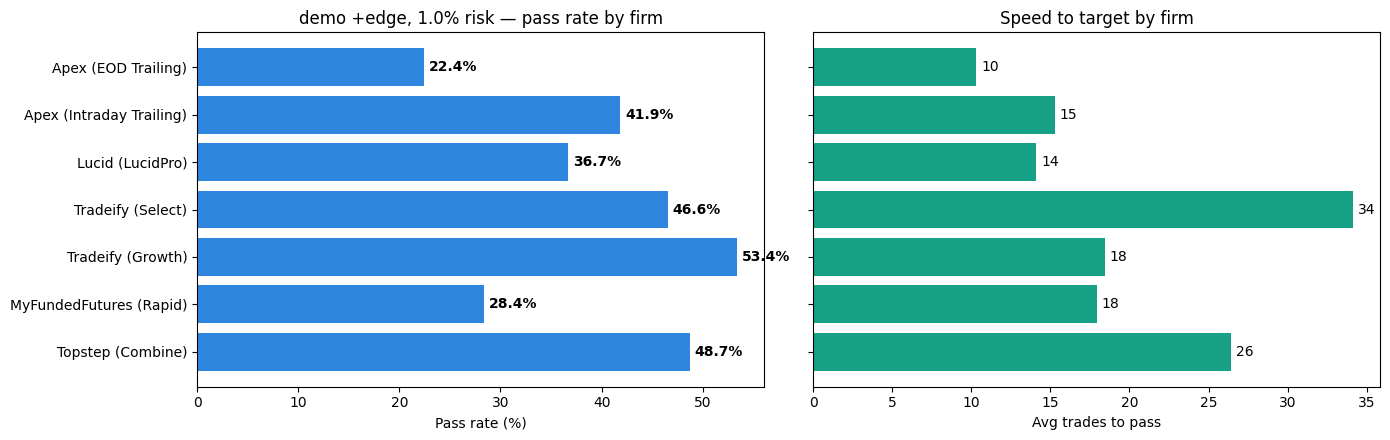

In [6]:
demo = SyntheticStrategy(win_rate=0.45, rr=1.5, name="demo +edge")
order = ['apex_eod','apex_intraday','lucid','tradeify_select',
         'tradeify_growth','mffu_rapid','topstep']
rows = []
for k in order:
    f = get_firm(k)
    r = simulate(demo, f, f.start_balance*RISK_PCT/100, n_paths=6000,
                 max_trades=500, trades_per_day=TRADES_PER_DAY, seed=7)
    rows.append((f.name, r.pass_rate*100, r.mean_trades_to_pass))

names=[x[0] for x in rows]; prs=[x[1] for x in rows]; sp=[x[2] for x in rows]
y=np.arange(len(names))[::-1]
fig,ax=plt.subplots(1,2,figsize=(14,4.5))
ax[0].barh(y,prs,color='#2e86de')
for yi,v in zip(y,prs): ax[0].text(v+0.5,yi,f'{v:.1f}%',va='center',fontweight='bold')
ax[0].set_yticks(y); ax[0].set_yticklabels(names); ax[0].set_xlabel('Pass rate (%)')
ax[0].set_title(f'{demo.name}, {RISK_PCT}% risk — pass rate by firm')
ax[1].barh(y,[0 if np.isnan(v) else v for v in sp],color='#16a085')
for yi,v in zip(y,sp):
    if not np.isnan(v): ax[1].text(v+0.3,yi,f'{v:.0f}',va='center')
ax[1].set_yticks(y); ax[1].set_yticklabels([]); ax[1].set_xlabel('Avg trades to pass')
ax[1].set_title('Speed to target by firm')
fig.tight_layout(); plt.show()


## Loading YOUR real strategy

Feed the engine per-trade **R-multiples** from your BOS/SuperTrend/EMA backtest
(`R = pnl / risk_on_that_trade`). Below loads the example; point it at your file
or build an `EmpiricalStrategy` from a CSV.

In [7]:
import importlib.util
spec = importlib.util.spec_from_file_location("bos", "strategies/example_bos.py")
mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(mod)
my_strat = mod.get_strategy()
print(f"{my_strat.name}: edge = {my_strat.expectancy_R:+.3f} R/trade")

# From a CSV instead:
#   import pandas as pd
#   pnl = pd.read_csv("bos_trades.csv")["pnl"].to_numpy()
#   my_strat = EmpiricalStrategy(pnl / 200.0, name="BOS 5m")   # if you risked $200/trade

res = simulate(my_strat, FIRM, RISK_DOLLARS, n_paths=8000,
               max_trades=500, trades_per_day=TRADES_PER_DAY, seed=1)
print(f"On {FIRM.name}: pass={res.pass_rate:.1%}  fail={res.fail_rate:.1%}  "
      f"ongoing={res.ongoing_rate:.1%}  avg trades to pass={res.mean_trades_to_pass:.0f}")


BOS (example): edge = +0.274 R/trade
On Apex (Intraday Trailing): pass=54.8%  fail=45.2%  ongoing=0.0%  avg trades to pass=12
